In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
df = pd.read_excel("../data/Cleaned_Road_Safety_Data_Fixed.xlsx")

df.head()

,Year,Registered Vehicles,Population,Road Crashes,Road Deaths,Serious Injury,Slight Injury,"Index per 10,000 Vehicles","Index per 100,000 Population",Index per billion VKT,...,Bicycle,Bus,Jeep,Motorcar,Motorcycle,Others,Pedestrian,Trailer/Lorry,Vans,Fatality_Rate_per_100k
0,2000,10598804,23494900,250429,6035,9790,34375,5.694039,25.686426,26.25,...,2128,530,555,6720,33645,4395,0,1065,1156,25.686426
1,2001,11302545,24030500,265175,5849,8680,35944,5.174941,24.339901,23.93,...,2208,628,487,7231,33627,4311,0,921,1060,24.339901
2,2002,12068144,24542500,279711,5891,8425,35236,4.881447,24.003260,22.71,...,514,868,335,3054,8782,1367,0,131,546,24.003260
3,2003,12819248,25038100,298653,6286,9040,37415,4.903564,25.105739,22.77,...,2226,529,573,8127,34248,706,4049,1227,1056,25.105739
4,2004,13764837,25541500,326815,6228,9218,38645,4.524572,24.383846,21.10,...,2354,512,585,8340,35727,446,3980,1226,921,24.383846


In [11]:
X = df[['Year']]

y = df['Road Deaths']

In [12]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = model.predict(X)

print(y_pred)

[5924.1372549  5995.70098039 6067.26470588 6138.82843137 6210.39215686
 6281.95588235 6353.51960784 6425.08333333 6496.64705882 6568.21078431
 6639.7745098  6711.33823529 6782.90196078 6854.46568627 6926.02941176
 6997.59313725 7069.15686275]


In [14]:
mae = mean_absolute_error(y, y_pred)

r2 = r2_score(y, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 136.25259515571045
R² Score: 0.8362801021252191


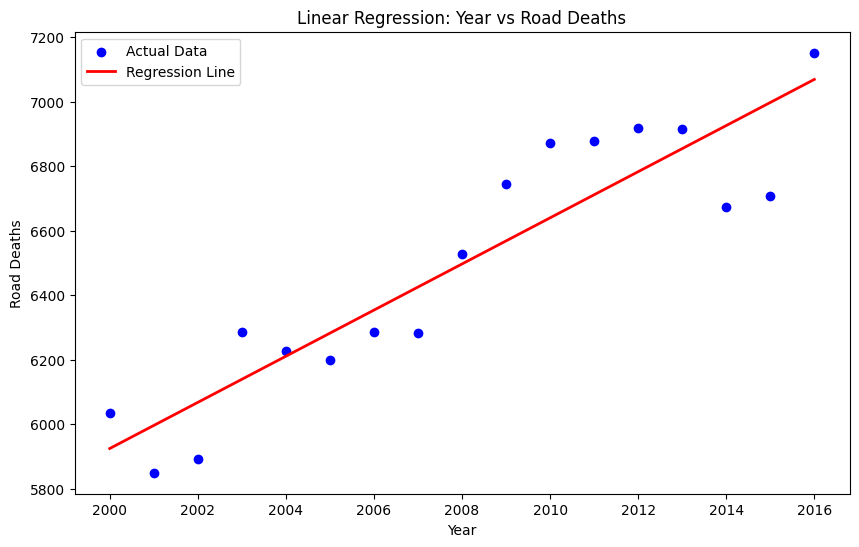

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Year")
plt.ylabel("Road Deaths")
plt.title("Linear Regression: Year vs Road Deaths")

plt.legend()

plt.show()

In [16]:
future_years = pd.DataFrame({
    'Year': [2020, 2025, 2030]
})

future_predictions = model.predict(future_years)

for year, prediction in zip(future_years['Year'], future_predictions):
    print(f"Predicted Road Deaths for {year}: {prediction:.0f}")

Predicted Road Deaths for 2020: 7355
Predicted Road Deaths for 2025: 7713
Predicted Road Deaths for 2030: 8071


In [18]:
X_multi = df[['Year',
              'Registered Vehicles',
              'Population',
              'Road Crashes']]

y_multi = df['Road Deaths']

In [19]:
multi_model = LinearRegression()

multi_model.fit(X_multi, y_multi) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_multi_pred = multi_model.predict(X_multi)

multi_mae = mean_absolute_error(y_multi, y_multi_pred)

multi_r2 = r2_score(y_multi, y_multi_pred)

print("Multiple Regression MAE:", multi_mae)
print("Multiple Regression R²:", multi_r2)

Multiple Regression MAE: 102.58811051979222
Multiple Regression R²: 0.9130359973108655


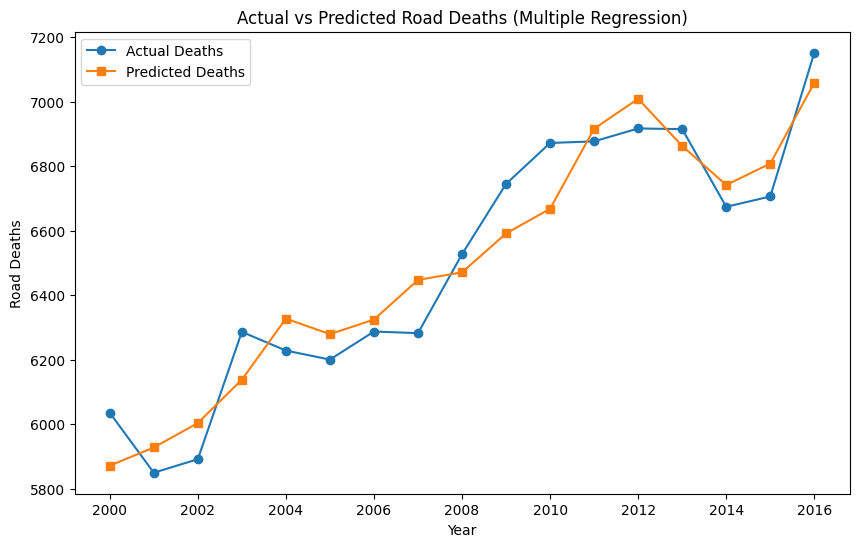

In [21]:
plt.figure(figsize=(10,6))

plt.plot(df['Year'], y_multi, marker='o', label='Actual Deaths')

plt.plot(df['Year'], y_multi_pred, marker='s', label='Predicted Deaths')

plt.xlabel("Year")
plt.ylabel("Road Deaths")
plt.title("Actual vs Predicted Road Deaths (Multiple Regression)")

plt.legend()

plt.show()

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
})

print(feature_importance)

               Feature  Coefficient
0                 Year   596.554499
1  Registered Vehicles    -0.000089
2           Population    -0.001134
3         Road Crashes     0.008788
